In [1]:
import numpy as np

import torch
import torch.nn as nn
from torch.autograd import Variable

torch.manual_seed(69)
torch.cuda.manual_seed(69)

import sys
import platform
import matplotlib.pyplot as plt

from numpy.fft  import fft, ifft,fft2, ifft2,fftn, ifftn
from scipy import signal
import os
import scipy
import time

has_gpu = torch.cuda.is_available()
has_mps = torch.backends.mps.is_built()
device = "mps" if torch.backends.mps.is_built() \
    else "cuda:0" if torch.cuda.is_available() else "cpu"

print(f"Python Platform: {platform.platform()}")
print(f"PyTorch Version: {torch.__version__}")

# print(f"Scikit-Learn {sk.__version__}")
print("GPU is", "available" if has_gpu else "NOT AVAILABLE")
print("MPS (Apple Metal) is", "AVAILABLE" if has_mps else "NOT AVAILABLE")
print(f"Target device is {device}")

Python Platform: Windows-11-10.0.26100-SP0
PyTorch Version: 2.6.0+cu124
GPU is available
MPS (Apple Metal) is NOT AVAILABLE
Target device is cuda:0


## Defining the Neural Network

In [2]:
class Sin(nn.Module):
    def forward(self, input):
        return torch.sin(input)

class PINN(nn.Module):
    def __init__(self, num_neurons=48):
        super(PINN, self).__init__()
        self.num_neurons = num_neurons
    
    # 1D branch (x, t)
        self.branch_1d = nn.Sequential(
            nn.Linear(2, num_neurons),
            Sin(),
            nn.Linear(num_neurons, num_neurons),
            Sin(),
            nn.Linear(num_neurons, 3))
        
    # 2D branch (x, y, t)
        self.branch_2d = nn.Sequential(
            nn.Linear(3, num_neurons),
            Sin(),
            nn.Linear(num_neurons, num_neurons),
            Sin(),
            nn.Linear(num_neurons, num_neurons),
            Sin(),
            nn.Linear(num_neurons, num_neurons),
            Sin(),
            nn.Linear(num_neurons, 4))
        
    # 3D branch (x, y, z, t)
        self.branch_3d = nn.Sequential(
            nn.Linear(4, num_neurons),
            Sin(),
            nn.Linear(num_neurons, num_neurons),
            Sin(),
            nn.Linear(num_neurons, 5))
        
        # Output layers per branch
        #self.output_layer_1d = nn.Linear(3, 1)
        #self.output_layer_2d = nn.Linear(4, 1)
        #self.output_layer_3d = nn.Linear(5, 1)


    def forward(self,X):
        x, t = X[0],X[-1]
        x = x.unsqueeze(-1) if x.dim() == 1 else x
        t = t.unsqueeze(-1) if t.dim() == 1 else t

        if len(X) == 2:
            inputs = torch.cat([x, t], dim=1)
            return self.branch_1d(inputs)
        
        elif len(X) == 3:
            y = X[1]
            y = y.unsqueeze(-1) if y.dim() == 1 else y

            inputs = torch.cat([x, y, t], dim=1)
            return self.branch_2d(inputs)
        
        elif len(X) == 4:
            y = X[1]
            z = X[2]
            y = y.unsqueeze(-1) if y.dim() == 1 else y
            z = z.unsqueeze(-1) if z.dim() == 1 else z

            inputs = torch.cat([x, y, z, t], dim=1)
            return self.branch_3d(inputs)
        
        else:
            raise ValueError(f"Expected len(X) in [2, 3, 4] but got {len(X)}")
        
def init_weights(m):
    if isinstance(m, nn.Linear):
        torch.nn.init.xavier_uniform_(m.weight)
        m.bias.data.fill_(0.01)


In [3]:
def diff(u,var,order=1): #The derivative of a variable with respect to another.
    
    u.requires_grad_()
    var.requires_grad_()
    ones = torch.ones_like(u)
    der, = torch.autograd.grad(u, var, create_graph=True, grad_outputs=ones, allow_unused=True)
    if der is None:
        return torch.zeros_like(var, requires_grad=True)
    else:
        der.requires_grad_()
    for i in range(1, order):
        ones = torch.ones_like(der)
        der, = torch.autograd.grad(der, var, create_graph=True, grad_outputs=ones, allow_unused=True)
        if der is None:
            return torch.zeros_like(var, requires_grad=True)
        else:
            der.requires_grad_()
    return der


class col_gen(object):

    def __init__(self, rmin=[0,0,0,0], rmax=[1,1,1,1], N_0 = 1000, N_b = 1000, N_r = 3000, dimension=1):
        
        '''
        This function accepts the range of the computational domain and returns the collocation points depending on the dimension

        xmin=0, xmax=1,: Default is seto to 0 and 1 for xmin and xmax respestively 
        ymin=0, ymax=0 : Default is set is to 0 when only dimension 1 is used
        zmin=0, zmax=0 : Default is set is to 0 when only dimension 1 & 2 is used
        tmin=0, tmax=1 : Default is set is to 0 and 1 
        N_0: Number of collocation points for the IC Default is set to 1000
        N_B: Number of collocation points for the main Domain: Default is set to 1000
        N_r: Number of collocation points for the main Domain: Default is set to 3000
        dimension : Spacial Dimension
               
        
        '''
    
        self.rmin = rmin
        self.rmax = rmax
        self.N_0 = N_0
        self.N_b = N_b
        self.N_r = N_r
        self.dimension = dimension
        
        
    def geo_time_coord(self,option,coordinate=1):
        '''
        option: Takes arguments: "Domain", "BC" for Boundary conditions, "IC" for initial conditions:
        
        '''
        
        if self.dimension == 1: 
            if option == "Domain":
                coor = []
                x_coor = torch.cuda.FloatTensor(self.N_r,1).uniform_(self.rmin[0], self.rmax[0]).requires_grad_()
                coor.append(x_coor)
                t_coor = t_collocation=torch.cuda.FloatTensor(self.N_r,1).uniform_(self.rmin[1], self.rmax[1]).requires_grad_()
                coor.append(t_coor)

                return coor

            if option == "IC": ## Intial conditions collocation points

                coor = []
                x_0 = torch.cuda.FloatTensor(self.N_0,1).uniform_(self.rmin[0], self.rmax[0]).requires_grad_()
                coor.append(x_0)

                t_0 = torch.cuda.FloatTensor(self.N_0,1).fill_(0).requires_grad_()
                coor.append(t_0)

                return coor

            if option == "BC":
                coor_l = []
                coor_r = []
                x_bc_l = torch.cuda.FloatTensor(self.N_b,1).fill_(self.rmin[coordinate-1]).requires_grad_()
                x_bc_r = torch.cuda.FloatTensor(self.N_b,1).fill_(self.rmax[coordinate-1]).requires_grad_()
                t_bc   = torch.cuda.FloatTensor(self.N_b,1).uniform_(self.rmin[self.dimension], self.rmax[self.dimension])

                coor_l.append(x_bc_l)
                coor_l.append(t_bc)

                coor_r.append(x_bc_r)
                coor_r.append(t_bc)

                return  coor_l, coor_r
            
        if self.dimension == 2:
            if option == "Domain":
                
                coor = []
                for d in range(self.dimension+1): ## +1 for the time dimension
                    temp_coor = torch.cuda.FloatTensor(self.N_r,1).uniform_(self.rmin[d], self.rmax[d]).requires_grad_()
                    coor.append(temp_coor)

                return coor
            
            if option == "IC": ## Intial conditions collocation points
                coor = []
                for d in range(self.dimension): ## time is zero as it is the initial condition
                    temp_coor = torch.cuda.FloatTensor(self.N_0,1).uniform_(self.rmin[d], self.rmax[d]).requires_grad_()
                    coor.append(temp_coor)

                t_0 = torch.cuda.FloatTensor(self.N_0,1).fill_(0).requires_grad_()
                coor.append(t_0)

                return coor
            
            if option == "BC":
                t_bc   = torch.cuda.FloatTensor(self.N_b,1).uniform_(self.rmin[self.dimension], self.rmax[self.dimension])
                t_bc.requires_grad_()
        
                if coordinate == 1: 
                    
                    x_bc_l = torch.cuda.FloatTensor(self.N_b,1).fill_(self.rmin[coordinate-1]).requires_grad_()
                    x_bc_r = torch.cuda.FloatTensor(self.N_b,1).fill_(self.rmax[coordinate-1]).requires_grad_()                   
                    y_bc   = torch.cuda.FloatTensor(self.N_b,1).uniform_(self.rmin[coordinate], self.rmax[coordinate]).requires_grad_()
                    
                    coor_l = []
                    coor_r = []
                    coor_l.append(x_bc_l)
                    coor_l.append(y_bc)
                    coor_l.append(t_bc)
                    
                    
                    coor_r.append(x_bc_r)
                    coor_r.append(y_bc)
                    coor_r.append(t_bc)
                    
                    return coor_l , coor_r
                   
                 
                if coordinate == 2:
                    y_bc_l = torch.cuda.FloatTensor(self.N_b,1).fill_(self.rmin[coordinate-1]).requires_grad_()
                    y_bc_r = torch.cuda.FloatTensor(self.N_b,1).fill_(self.rmax[coordinate-1]).requires_grad_()
                    x_bc   = torch.cuda.FloatTensor(self.N_b,1).uniform_(self.rmin[coordinate-2], self.rmax[coordinate-2]).requires_grad_()            
                    
                    coor_l = []
                    coor_r = []
                    coor_l.append(x_bc)
                    coor_l.append(y_bc_l)
                    coor_l.append(t_bc)
                    
                    
                    coor_r.append(x_bc)
                    coor_r.append(y_bc_r)
                    coor_r.append(t_bc)
                    
                    return coor_l, coor_r
    
            
        if self.dimension == 3: 
            if option == "Domain":
                
                coor = []
                for d in range(self.dimension+1): ## +1 for the time dimension
                    temp_coor = torch.cuda.FloatTensor(self.N_r,1).uniform_(self.rmin[d], self.rmax[d]).requires_grad_()
                    coor.append(temp_coor)
                
                return coor

            if option == "IC": ## Intial conditions collocation points
                coor = []
                for d in range(self.dimension): ## time is zero as it is the initial condition                  
                    temp_coor = torch.cuda.FloatTensor(self.N_0,1).uniform_(self.rmin[d], self.rmax[d]).requires_grad_()
                    coor.append(temp_coor)
                
                t_0 = torch.cuda.FloatTensor(self.N_0,1).fill_(0).requires_grad_()
                coor.append(t_0)
                
                return coor
             

            if option == "BC":                
                t_bc   = torch.cuda.FloatTensor(self.N_b,1).uniform_(self.rmin[self.dimension], self.rmax[self.dimension])
                t_bc.requires_grad_()
        
                if coordinate == 1: 
                    
                    x_bc_l = torch.cuda.FloatTensor(self.N_b,1).fill_(self.rmin[coordinate-1]).requires_grad_()
                    x_bc_r = torch.cuda.FloatTensor(self.N_b,1).fill_(self.rmax[coordinate-1]).requires_grad_()                   
                    y_bc   = torch.cuda.FloatTensor(self.N_b,1).uniform_(self.rmin[coordinate], self.rmax[coordinate]).requires_grad_()
                    z_bc   = torch.cuda.FloatTensor(self.N_b,1).uniform_(self.rmin[coordinate+1], self.rmax[coordinate+1]).requires_grad_()
                    
                    coor_l = []
                    coor_r = []
                    coor_l.append(x_bc_l)
                    coor_l.append(y_bc)
                    coor_l.append(z_bc)
                    coor_l.append(t_bc)
                    
                    
                    coor_r.append(x_bc_r)
                    coor_r.append(y_bc)
                    coor_r.append(z_bc)
                    coor_r.append(t_bc)
                    
                    return coor_l , coor_r
                   
                 
                if coordinate == 2:
                    y_bc_l = torch.cuda.FloatTensor(self.N_b,1).fill_(self.rmin[coordinate-1]).requires_grad_()
                    y_bc_r = torch.cuda.FloatTensor(self.N_b,1).fill_(self.rmax[coordinate-1]).requires_grad_()
                    x_bc   = torch.cuda.FloatTensor(self.N_b,1).uniform_(self.rmin[coordinate-2], self.rmax[coordinate-2]).requires_grad_()            
                    z_bc   = torch.cuda.FloatTensor(self.N_b,1).uniform_(self.rmin[coordinate], self.rmax[coordinate]).requires_grad_()
                
                    coor_l = []
                    coor_r = []
                    coor_l.append(x_bc)
                    coor_l.append(y_bc_l)
                    coor_l.append(z_bc)
                    coor_l.append(t_bc)
                    
                    
                    coor_r.append(x_bc)
                    coor_r.append(y_bc_r)
                    coor_r.append(z_bc)
                    coor_r.append(t_bc)
                    
                    return coor_l, coor_r
                    
                   
                if coordinate == 3:
                    
                    z_bc_l = torch.cuda.FloatTensor(self.N_b,1).fill_(self.rmin[coordinate-1]).requires_grad_()
                    z_bc_r = torch.cuda.FloatTensor(self.N_b,1).fill_(self.rmax[coordinate-1]).requires_grad_()
                    x_bc   = torch.cuda.FloatTensor(self.N_b,1).uniform_(self.rmin[coordinate-3], self.rmax[coordinate-3]).requires_grad_()
                    y_bc   = torch.cuda.FloatTensor(self.N_b,1).uniform_(self.rmin[coordinate-2], self.rmax[coordinate-2]).requires_grad_()
                    
                    coor_l = []
                    coor_r = []
                    coor_l.append(x_bc)
                    coor_l.append(y_bc)
                    coor_l.append(z_bc_l)
                    coor_l.append(t_bc)
                    
                    
                    coor_r.append(x_bc)
                    coor_r.append(y_bc)
                    coor_r.append(z_bc_r)
                    coor_r.append(t_bc)
                    
                    return coor_l , coor_r

In [4]:
class ASTPN(col_gen):  
    
    def __init__(self, rmin=[0,0,0,0], rmax=[1,1,1,1], N_0 = 1000, N_b=1000, N_r=3000, dimension=1):
        super().__init__(rmin,rmax, N_0,N_b,N_r, dimension)
        
       
        self.coord_Lx, self.coord_Rx = self.geo_time_coord(option="BC",coordinate=1)
        
        if dimension == 2:
            self.coord_Ly, self.coord_Ry = self.geo_time_coord(option="BC",coordinate=2)

        if dimension == 3:
            self.coord_Ly, self.coord_Ry = self.geo_time_coord(option="BC",coordinate=2)
            self.coord_Lz, self.coord_Rz = self.geo_time_coord(option="BC",coordinate=3)
    
    
    
    def periodic_BC(self,net,coordinate=1,derivative_order=0,component=0):
        
        '''
           INPUT: geomtime: The collocatin grids
           since it is BC the derivative always wrt to spacial coordinate: coordinate =1 is the first x coordinate
           derivative order: what order derivative
           component: output component's derivative is taken component = 0 is the First output fron the network
           default is set to 0,i.e., the first output
           coordinate : 1: xaxis (default), 2: with y axis 3: with zaxis
         '''

        if coordinate==1:   
            coord_L, coord_R = self.coord_Lx, self.coord_Rx
        if coordinate==2:       
            coord_L, coord_R = self.coord_Ly, self.coord_Ry
        if coordinate==3:       
            coord_L, coord_R = self.coord_Lz, self.coord_Rz
        
        
        # return coord_L, coord_R
          
        variable_l = net(coord_L)[:,component:component+1] 
        variable_r = net(coord_R)[:,component:component+1] 
        
        if derivative_order == 0:

            return torch.mean((variable_l - variable_r)**2)

        elif derivative_order == 1:        
            der_l = diff(variable_l,coord_L[coordinate-1],order=derivative_order)
            der_r = diff(variable_r,coord_R[coordinate-1],order=derivative_order)

            return torch.mean((der_l-der_r)**2)


def pde_residue(colloc, net, dimension = 1):
    
    '''
    This is the main function that returns all the PDE residue
    '''
    net_outputs = net(colloc)
    
    x = colloc[0]
    
    if dimension == 1:
        t = colloc[1]

    elif dimension == 2:
        y = colloc[1]
        t = colloc[2]

    elif dimension == 3:
        y = colloc[1]
        z = colloc[2]
        t = colloc[3]
    
    rho, vx = net_outputs[:,0:1], net_outputs[:,1:2]

    if dimension == 1:

        phi = net_outputs[:,2:3]

        rho_t = diff(rho,t,order=1)  
        rho_x = diff(rho,x,order=1)

        vx_t = diff(vx, t,order=1)
        vx_x = diff(vx, x,order=1)
        
        phi_x = diff(phi,x,order=1)
        phi_x_x = diff(phi,x,order=2)

    elif dimension == 2:

        vy = net_outputs[:,2:3]
        phi = net_outputs[:,3:4]

        rho_t = diff(rho,t,order=1)  
        rho_x = diff(rho,x,order=1)
        rho_y = diff(rho,y,order=1)

        vx_t = diff(vx, t,order=1)
        vy_t = diff(vy, t,order=1)

        vx_x = diff(vx, x,order=1)
        vx_y = diff(vx, y,order=1)
        vy_x = diff(vy, x,order=1)
        vy_y = diff(vy, y,order=1)
        
        phi_x = diff(phi,x,order=1)
        phi_x_x = diff(phi,x,order=2)

        phi_y = diff(phi,y,order=1)
        phi_y_y = diff(phi,y,order=2)

    elif dimension == 3:
        vy = net_outputs[:,2:3]
        vz = net_outputs[:,3:4]
        phi = net_outputs[:,4:5]

        rho_t = diff(rho,t,order=1)  
        rho_x = diff(rho,x,order=1)
        rho_y = diff(rho,y,order=1)
        rho_z = diff(rho,z,order=1)

        vx_t = diff(vx, t,order=1)
        vy_t = diff(vy, t,order=1)
        vz_t = diff(vz, t,order=1)

        vx_x = diff(vx, x,order=1)
        vy_x = diff(vy, x,order=1)
        vz_x = diff(vz, x,order=1)

        vx_y = diff(vx, y,order=1)
        vy_y = diff(vy, y,order=1)
        vz_y = diff(vz, y,order=1)
        
        vx_z = diff(vx, z,order=1)
        vy_z = diff(vy, z,order=1)
        vz_z = diff(vz, z,order=1)
        
        phi_x = diff(phi,x,order=1)
        phi_x_x = diff(phi,x,order=2)

        phi_y = diff(phi,y,order=1)
        phi_y_y = diff(phi,y,order=2)
    
        phi_z = diff(phi,z,order=1)
        phi_z_z = diff(phi,z,order=2)

    
    ## The residues from the equations

    if dimension == 1:
        rho_r = rho_t + vx * rho_x + rho * vx_x
        vx_r = rho*vx_t + rho*(vx*vx_x) + cs*cs*rho_x +rho*phi_x
        phi_r = phi_x_x - const*(rho - rho_o)

        return rho_r, vx_r, phi_r

    elif dimension == 2:
        rho_r = rho_t + vx * rho_x + vy * rho_y + rho * vx_x + rho * vy_y
        vx_r = rho*vx_t + rho*(vx*vx_x + vy*vx_y) + cs*cs*rho_x + rho*phi_x
        vy_r = rho*vy_t + rho*(vy*vy_y + vx*vy_x) + cs*cs*rho_y + rho*phi_y
        phi_r = phi_x_x + phi_y_y - const*(rho - rho_o)

        return rho_r, vx_r, vy_r, phi_r
    
    elif dimension == 3:
        rho_r = rho_t + vx * rho_x + rho * vx_x + vy *rho_y + rho * vy_y + vz *rho_z +rho * vz_z
        vx_r = rho*vx_t + rho*(vx*vx_x + vy*vx_y+vz*vx_z) + cs*cs*rho_x + rho*phi_x
        vy_r = rho*vy_t + rho*(vy*vy_y + vx*vy_x+vz*vy_z) + cs*cs*rho_y + rho*phi_y
        vz_r = rho*vz_t + rho*(vz*vz_z + vx*vz_x+vy*vz_y) + cs*cs*rho_z + rho*phi_z
        phi_r = phi_x_x + phi_y_y +phi_z_z - const*(rho - rho_o)
        
        return rho_r,vx_r,vy_r,vz_r,phi_r


In [16]:
## Setting up the problem

lam = 7.0          # one wavelength
num_of_waves = 2
cs = 1.0          # % Sound Speed

rho_1 = .3        # question 2a linear wave propagation
rho_o = 1          # zeroth order density
const = 1          ## we set 4 pi G  to 1
G = 1

'''output_folder = "1D_fig" 


try:
    os.makedirs(output_folder)
except OSError:
    print ("Creation of the directory %s failed/ not needed as it already exit" % output_folder)
else:
    print ("Successfully created the directory %s" % output_folder)'''
  

jeans = np.sqrt(4*np.pi**2*cs**2/(const*G*rho_o))

if lam> jeans:
    alpha = np.sqrt(const*G*rho_o-cs**2*(2*np.pi/lam)**2)
else:
    alpha = np.sqrt(cs**2*(2*np.pi/lam)**2 - const*G*rho_o)
    
# v_1 = (cs*rho_1)/rho_o # velocity perturbation without gravity
v_1  = (rho_1/rho_o) * (alpha/(2*np.pi/lam)) ## With gravity


def fun_rho_0(x):
    ''' Define initial condition for density Returning Eq (11a)'''
    # print('wavelength',lam)
    rho_0 = rho_o + rho_1 * torch.cos(2*np.pi*x[0]/lam)    
    return rho_0

def fun_v_0(x):
    '''initial condition for velocity -- Returning Eq 11b'''
    
    if lam > jeans:
        v_0 = - v_1 * torch.sin(2*np.pi*x[0]/lam)## This is for sound wave ## refer to the paper for details
    else:
        v_0 = v_1 * torch.cos(2*np.pi*x[0]/lam)  ## This is for the gravity wave
    return v_0

def func(x):
    return x[0]*0

## Model INITIALIZATION

In [17]:
# Set boundary
tmin = 0.
tmax = 2.
xmin = 0.
xmax = xmin+lam*num_of_waves
ymin= 0.
ymax= ymin+lam*num_of_waves
zmin= 0.
zmax= 1.

cs = 1.

N_0 = 1000
N_b = 1000
N_r = 15000

net = PINN()
net = net.to(device)
mse_cost_function = torch.nn.MSELoss() # Mean squared error
optimizer = torch.optim.Adam(net.parameters(),lr=0.001,)
optimizerL = torch.optim.LBFGS(net.parameters(),line_search_fn='strong_wolfe')

'''coor_l, coor_r = model.geo_time_coord(option="BC", coordinate=1)

# Print the lengths and values of coor_l and coor_r
print("Length of coor_l:", len(coor_l))
print("Length of coor_r:", len(coor_r))
print("coor_l:", coor_l)
print("coor_r:", coor_r)'''

#model_1D = ASTPN(rmin=[xmin, tmin],rmax=[xmax, tmax], N_0= N_0,N_b=N_b,N_r= N_r,dimension=1)
model_2D = ASTPN(rmin=[xmin, ymin, tmin],rmax=[xmax, ymax, tmax], N_0= N_0,N_b=N_b,N_r= N_r,dimension=2)
#model_3D = ASTPN(rmin=[xmin,ymin,zmin,tmin],rmax=[xmax,ymax,zmax,tmax], N_0 = N_0, N_b = N_b, N_r = N_r, dimension=3)

#collocation_domain_1D = model_1D.geo_time_coord(option= "Domain") 
#collocation_IC_1D = model_1D.geo_time_coord(option= "IC")

collocation_domain_2D = model_2D.geo_time_coord(option= "Domain")
collocation_IC_2D = model_2D.geo_time_coord(option= "IC")

#collocation_domain_3D = model_3D.geo_time_coord(option= "Domain")
#collocation_IC_3D = model_3D.geo_time_coord(option= "IC")

#print(len(collocation_domain), len(collocation_IC))

#print(min(collocation_domain[:,0:1]),np.shape(collocation_domain[:,0:1]))
#print(min(collocation_domain[:,1:2]),np.shape(collocation_domain[:,0:1]))
#print(min(collocation_domain[:,2:3]),np.shape(collocation_domain[:,0:1]))


#print(max(collocation_IC [:,0:1]),np.shape(collocation_IC [:,0:1]))
#print(min(collocation_IC [2]),np.shape(collocation_IC [2]))
#collocation_IC[3]

In [18]:
### (3) Training / Fitting
from tqdm import tqdm
iteration_adam = 800
iterationL = 100

#start = time.time()
def closure(model, collocation_domain, collocation_IC):

    ############## Loss based on initial conditions ###############
    rho_0 = fun_rho_0(collocation_IC)
    vx_0  = fun_v_0(collocation_IC)

    if model.dimension == 2:
        vy_0  = func(collocation_IC)

    elif model.dimension == 3:
        vy_0  = func(collocation_IC)
        vz_0  = func(collocation_IC)
    
    net_ic_out = net(collocation_IC)

    rho_ic_out = net_ic_out[:,0:1]
    vx_ic_out  = net_ic_out[:,1:2]

    if model.dimension == 2:
        vy_ic_out  = net_ic_out[:,2:3]
    elif model.dimension == 3:
        vy_ic_out  = net_ic_out[:,2:3]
        vz_ic_out  = net_ic_out[:,3:4]

    mse_rho_ic =  mse_cost_function(rho_ic_out, rho_0)
    mse_vx_ic  =  mse_cost_function(vx_ic_out, vx_0)

    if model.dimension == 2:
        mse_vy_ic  =  mse_cost_function(vy_ic_out, vy_0)

    elif model.dimension == 3:
        mse_vy_ic  =  mse_cost_function(vy_ic_out, vy_0)
        mse_vz_ic  =  mse_cost_function(vz_ic_out, vz_0)

    ############# Loss based on boundary conditions #################

    
    rhox_b     = model.periodic_BC(net,coordinate=1,derivative_order=0,component=0)
    
    vx_xb      = model.periodic_BC(net,coordinate=1,derivative_order=0,component=1)
       
    phi_xb     = model.periodic_BC(net,coordinate=1,derivative_order=0,component=2)
    phi_xx_b   = model.periodic_BC(net,coordinate=1,derivative_order=1,component=2)

    if model.dimension == 2 or model.dimension == 3:
        rhoy_b     = model.periodic_BC(net,coordinate=2,derivative_order=0,component=0)

        vx_yb      = model.periodic_BC(net,coordinate=2,derivative_order=0,component=1)
        vy_xb      = model.periodic_BC(net,coordinate=1,derivative_order=0,component=2)
        vy_yb      = model.periodic_BC(net,coordinate=2,derivative_order=0,component=2)

        phi_yb     = model.periodic_BC(net,coordinate=2,derivative_order=0,component=3)
        phi_yy_b   = model.periodic_BC(net,coordinate=2,derivative_order=1,component=3)

        if model.dimension == 3:
            rhoz_b     = model.periodic_BC(net,coordinate=3,derivative_order=0,component=0)

            vx_zb      = model.periodic_BC(net,coordinate=3,derivative_order=0,component=1)
            vy_yb      = model.periodic_BC(net,coordinate=2,derivative_order=0,component=2)
            vy_zb      = model.periodic_BC(net,coordinate=3,derivative_order=0,component=2)
    
            vz_xb      = model.periodic_BC(net,coordinate=1,derivative_order=0,component=3)
            vz_yb      = model.periodic_BC(net,coordinate=2,derivative_order=0,component=3)
            vz_zb      = model.periodic_BC(net,coordinate=3,derivative_order=0,component=3)

            phi_zb     = model.periodic_BC(net,coordinate=3,derivative_order=0,component=4)
            phi_zz_b   = model.periodic_BC(net,coordinate=3,derivative_order=1,component=4)


    ############## Loss based on PDE ###################################
    
    if model.dimension == 1:
        rho_r,vx_r,phi_r = pde_residue(collocation_domain, net, dimension = 1)

    elif model.dimension == 2:
        rho_r,vx_r,vy_r,phi_r = pde_residue(collocation_domain, net, dimension = 2)

    elif model.dimension == 3:
        rho_r,vx_r,vy_r,vz_r,phi_r = pde_residue(collocation_domain, net, dimension = 3)
    

    mse_rho  = torch.mean(rho_r ** 2)
    mse_velx = torch.mean(vx_r  ** 2)

    if model.dimension == 2:
        mse_vely = torch.mean(vy_r  ** 2)

    elif model.dimension == 3:
        mse_vely = torch.mean(vy_r  ** 2)
        mse_velz = torch.mean(vz_r  ** 2)
    
    mse_phi  = torch.mean(phi_r ** 2)

    ################### Combining the loss functions ####################
    if model.dimension == 1:
        loss = mse_rho_ic + mse_vx_ic + mse_rho + mse_velx + mse_phi + rhox_b + vx_xb + phi_xb + phi_xx_b

    elif model.dimension == 2:
        loss = mse_rho_ic + mse_vx_ic + mse_vy_ic + mse_rho + mse_velx + mse_vely + mse_phi + rhox_b + rhoy_b + \
        vx_xb + vx_yb + vy_xb + vy_yb + phi_xb + phi_yb + phi_xx_b  + phi_yy_b

    elif model.dimension == 3:
        loss = mse_rho_ic + mse_vx_ic + mse_vy_ic + mse_vz_ic + mse_rho + mse_velx + mse_vely + mse_velz + mse_phi + \
        rhox_b + rhoy_b + rhoz_b + vx_xb + vx_yb + vx_zb + vy_xb + vy_yb + vy_zb + vz_xb + vz_yb + vz_zb + \
        phi_xb + phi_yb + phi_zb + phi_xx_b  + phi_yy_b  + phi_zz_b

    
        #loss = mse_rho_ic + mse_vx_ic + mse_vy_ic + mse_vz_ic + \
        #rhox_b + rhoy_b + rhoz_b + vx_xb + vx_yb + vx_zb +  vy_xb + vy_yb + vy_zb + vz_xb + vz_yb + vz_zb + \
        #phi_xb + phi_xx_b + phi_yb + phi_yy_b +  phi_zb + phi_zz_b + mse_rho + mse_velx +  mse_vely + mse_velz + mse_phi 

    optimizer.zero_grad()
    loss.backward(retain_graph=True)
    
    return loss

#end = time.time()
#print("Total time = {} sec ".format(end - start))

In [ ]:
#1D

'''for i in tqdm(range(iteration_adam)):

    loss = optimizer.step(lambda: closure(model_1D, collocation_domain_1D, collocation_IC_1D))

    with torch.autograd.no_grad():
        
        if i % 50 == 0:
            print(f"Training Loss at {i} for Adam in 1D system = {loss.item():.2e}")
            
for i in tqdm(range(iterationL)):

    loss = optimizerL.step(lambda: closure(model_1D, collocation_domain_1D, collocation_IC_1D))

    with torch.autograd.no_grad():
        
        if i % 50 == 0:
            print(f"Training Loss at {i} for LBGFS in 1D system = {loss.item():.2e}")'''

  2%|▏         | 4/200 [00:00<00:14, 13.25it/s]

Training Loss at 0 for Adam in 1D system = 2.00e+00


 27%|██▋       | 54/200 [00:01<00:04, 34.82it/s]

Training Loss at 50 for Adam in 1D system = 4.27e-02


 53%|█████▎    | 106/200 [00:03<00:02, 36.14it/s]

...

 52%|█████▏    | 103/200 [00:38<00:05, 17.95it/s]

Training Loss at 100 for LBGFS in 1D system = 1.01e-06


 77%|███████▋  | 154/200 [00:41<00:02, 17.77it/s]

Training Loss at 150 for LBGFS in 1D system = 1.01e-06


100%|██████████| 200/200 [00:44<00:00,  4.48it/s]


In [19]:
#2D

for i in tqdm(range(iteration_adam)):

    loss = optimizer.step(lambda: closure(model_2D, collocation_domain_2D, collocation_IC_2D))

    with torch.autograd.no_grad():
        
        if i % 100 == 0:
            print(f"Training Loss at {i} for Adam in 1D system = {loss.item():.2e}")

for i in tqdm(range(iterationL)):

    loss = optimizerL.step(lambda: closure(model_2D, collocation_domain_2D, collocation_IC_2D))

    with torch.autograd.no_grad():
        
        if i % 50 == 0:
            print(f"Training Loss at {i} for LBGFS in 1D system = {loss.item():.2e}")

  0%|          | 0/800 [00:00<?, ?it/s]

  0%|          | 2/800 [00:00<02:56,  4.52it/s]

Training Loss at 0 for Adam in 1D system = 1.71e+00


 13%|█▎        | 102/800 [00:12<01:29,  7.76it/s]

Training Loss at 100 for Adam in 1D system = 4.38e-02


...

  1%|          | 1/100 [00:03<05:49,  3.53s/it]

Training Loss at 0 for LBGFS in 1D system = 4.26e-03


 51%|█████     | 51/100 [03:14<04:24,  5.39s/it]

Training Loss at 50 for LBGFS in 1D system = 1.96e-04


100%|██████████| 100/100 [08:49<00:00,  5.29s/it]


In [ ]:
#3D

'''for i in tqdm(range(iteration_adam)):

    optimizer.zero_grad() # to make the gradients zero

    loss = optimizer.step(lambda: closure(model_3D, collocation_domain_3D, collocation_IC_3D))

    with torch.autograd.no_grad():
        
        if i % 250 == 0:
            print(f"Training Loss at {i} for Adam in 3D system = {loss.item():.2e}")

for i in tqdm(range(iterationL)):
    
    optimizer.zero_grad() # to make the gradients zero

    loss = optimizerL.step(lambda: closure(model_3D, collocation_domain_3D, collocation_IC_3D))

    with torch.autograd.no_grad():
        
        if i % 250 == 0:
            print(f"Training Loss at {i} for LBGFS in 3D system = {loss.item():.2e}")'''

  0%|          | 1/1000 [00:00<06:21,  2.62it/s]

Training Loss at 0 for Adam in 1D system = 1.79e+00


 25%|██▌       | 251/1000 [01:48<05:20,  2.34it/s]

Training Loss at 250 for Adam in 1D system = 7.33e-03


 50%|█████     | 501/1000 [03:32<03:33,  2.34it/s]

...

 50%|█████     | 501/1000 [23:45<06:24,  1.30it/s]

Training Loss at 500 for LBGFS in 1D system = 1.96e-06


 75%|███████▌  | 751/1000 [26:13<02:14,  1.85it/s]

Training Loss at 750 for LBGFS in 1D system = 1.96e-06


100%|██████████| 1000/1000 [28:12<00:00,  1.69s/it]


In [20]:
def plot_function(net,time_array,initial_params,velocity = False,isplot =False ,animation=False):
    xmin,xmax,rho_1, alpha,lam,tmax = initial_params  
    rho_o = 1.0          # zeroth order density
    num_of_waves = xmax-xmin/lam

    res = 200
    
    Y_cut = Z_cut = 0.5
    if animation:
        ## Converting the float (time-input) to an numpy array for animation
        ## Ignore this when the function is called in isolation
        time_array = np.array([time_array])
        # print("time",np.asarray(time_array))
    
    rho_max_Pinns = []    
    peak_lst=[]
    pert_xscale=[]
    for t in time_array:
        print("Plotting at t=", t)
        X = np.linspace(xmin,xmax,res).reshape(res, 1)
        Y = Y_cut*np.ones(res).reshape(res, 1)
        Z = Z_cut*np.ones(res).reshape(res, 1)
        t_ = t*np.ones(res).reshape(res, 1)
        pt_x_collocation = Variable(torch.from_numpy(X).float(), requires_grad=True).to(device)
        pt_y_collocation = Variable(torch.from_numpy(Y).float(), requires_grad=True).to(device)
        #pt_z_collocation = Variable(torch.from_numpy(Z).float(), requires_grad=True).to(device)
        pt_t_collocation = Variable(torch.from_numpy(t_).float(), requires_grad=True).to(device)
        test_coor = []
        test_coor.append(pt_x_collocation)
        test_coor.append(pt_y_collocation)
        #test_coor.append(pt_z_collocation)
        test_coor.append(pt_t_collocation)
        # X_0 = np.hstack((pt_x_collocation,pt_t_collocation))
        # test_coor = torch.cat([pt_x_collocation,pt_y_collocation, pt_z_collocation,pt_t_collocation],axis=1)
        output_0 = net(test_coor)
        
        rho_pred0 = output_0[:,0:1].data.cpu().numpy()
        print(np.shape(rho_pred0))
        vx_pred0 = output_0[:, 1:2].data.cpu().numpy()
        phi_pred0=output_0[:, 3:4].data.cpu().numpy()
 
        rho_max_PN = np.max(rho_pred0)
        ## Theoretical Values
        rho_theory = rho_o + rho_1*np.exp(alpha * t)*np.cos(2*np.pi*X[:, 0:1]/lam)
        vx_theory = -v_1*np.exp(alpha * t)*np.sin(2*np.pi*X[:, 0:1]/lam) if lam > jeans else v_1*np.exp(alpha * t)*np.cos(2*np.pi*X[:, 0:1]/lam) ## velocity theory
        
        ## Theoretical Values
        rho_theorymax = np.max(rho_o + rho_1*np.exp(alpha * t)*np.cos(2*np.pi*X[:, 0:1]/lam))
        rho_theory0 = np.max(rho_o + rho_1*np.exp(alpha * 0)*np.cos(2*np.pi*X[:, 0:1]/lam)) ## at t =0

        diff=abs(rho_max_PN-rho_theory)/abs(rho_max_PN+rho_theory) * 2  ## since the den is rhomax+rhotheory

        
        ### Difference between peaks for the PINNs solution
        
        rho_pred0Flat=rho_pred0.reshape(-1)
        peaks,_=scipy.signal.find_peaks(rho_pred0Flat)
        peak_lst.append(peaks)
        
        growth_pert=(rho_theorymax-rho_theory0)/rho_theory0*100 ## growth percentage
        
        # peak_diff=(rho_pred0Flat[peaks[1]]-rho_pred0Flat[peaks[0]])/(rho_pred0Flat[peaks[1]]+rho_pred0Flat[peaks[0]])

        #g_pred0=phi_x = dde.grad.jacobian(phi_pred0, X, i=0, j=0)
        if isplot:              
            print("rho_theory_max={} at time {}".format(rho_theorymax,t))
            plt.figure(1)
            plt.plot(X,rho_pred0,label="t={}".format(round(t,2)))
            #plt.plot(X[:, 0:1],rho_theory,'--',label="LT" )
            plt.ylabel(r"$\rho$")
            plt.xlabel("x")
            plt.legend(numpoints=1,loc='upper right',fancybox=True,shadow=True)
            # plt.title("Pinns Solution for $\lambda = {}$".format(lam))
            plt.title(r"Pinns Solution for $\lambda$ = {} $\lambda_J$ ".format(round(lam/(2*np.pi),2)))
            #plt.savefig(output_folder+'/PINNS_density'+str(lam)+'_'+str(num_of_waves)+'_'+str(tmax)+'.png', dpi=300)


            if velocity == True:
              plt.figure(2)
              plt.plot(X,vx_pred0,label="t={}".format(round(t,2)))
              #plt.plot(X[:, 0:1],vx_theory,'--',label="LT" )
              plt.ylabel("$v$")
              plt.xlabel("x")
              plt.title("Pinns Solution Velocity")
              plt.legend(numpoints=1,loc='upper right',fancybox=True,shadow=True)
              #plt.savefig(output_folder+'/PINNS_velocity'+str(lam)+'_'+str(num_of_waves)+'_'+str(tmax)+'.png', dpi=300)


            plt.figure(3)
            plt.plot(X,phi_pred0,label="t={}".format(round(t,2)))
            plt.ylabel(r"$\phi$")
            plt.xlabel("x")
            plt.title("Pinns Solution phi")
            plt.legend(numpoints=1,loc='upper right',fancybox=True,shadow=True)
            #plt.savefig(output_folder+'/phi'+str(lam)+'_'+str(num_of_waves)+'_'+str(tmax)+'.png', dpi=300)

            plt.figure(4)
            
            plt.scatter(t,rho_max_PN)
            plt.plot(t,rho_theorymax,marker='^',label="LT")
            plt.legend(numpoints=1,loc='upper left',fancybox=True,shadow=True)
    #         plt.axhline(rho_theory , color = 'r', linestyle = '--')
            plt.xlabel("t")
            plt.ylabel(r"$\rho_{\rm max}$")
            #plt.savefig(output_folder+'/rho_max'+str(lam)+'_'+str(num_of_waves)+'_'+str(tmax)+'.png', dpi=300)
            
            
#             plt.figure(6)
#             plt.scatter(growth_pert,peak_diff*100)
#             plt.ylabel("peak difference $\%$")
#             plt.xlabel("growth $\%$")
#             #plt.legend(numpoints=1,loc='upper right',fancybox=True,shadow=True)
#             # plt.savefig('lambda7_peak_diff_growth.png')
#             # plt.grid(True)
#             plt.title('DIF bet 1st and central peak')
#             plt.savefig(output_folder+'/gwt2'+str(lam)+'_'+str(num_of_waves)+'_'+str(tmax)+'.png', dpi=300)
            
#             plt.figure(7)
#             plt.scatter(growth_pert,diff*100)
#             plt.ylabel("rel DIF-FD-PINN $\%$")
#             plt.xlabel("growth $\%$")
#             #plt.legend(numpoints=1,loc='upper right',fancybox=True,shadow=True)
#             # plt.savefig('lambda7_peak_diff_growth.png')
#             # plt.grid(True)
#             plt.title('relative DIF-FD-PINN')
#             plt.savefig(output_folder+'/gwt1'+str(lam)+'_'+str(num_of_waves)+'_'+str(tmax)+'.png', dpi=300)
        
        else:  
            if animation:
                return X,rho_pred0,vx_pred0,phi_pred0,rho_max_PN,rho_theory
            else:
                return X ,rho_pred0,rho_max_PN,rho_theory 


#         plt.show()

Plotting at t= 0.0
(200, 1)
rho_theory_max=1.3 at time 0.0
Plotting at t= 0.5
(200, 1)
rho_theory_max=1.3739754136080253 at time 0.5
Plotting at t= 1.0
(200, 1)
rho_theory_max=1.4661920332776457 at time 1.0
Plotting at t= 1.5
(200, 1)
rho_theory_max=1.5811478615525796 at time 1.5
Plotting at t= 2.0
(200, 1)
rho_theory_max=1.724450039638485 at time 2.0


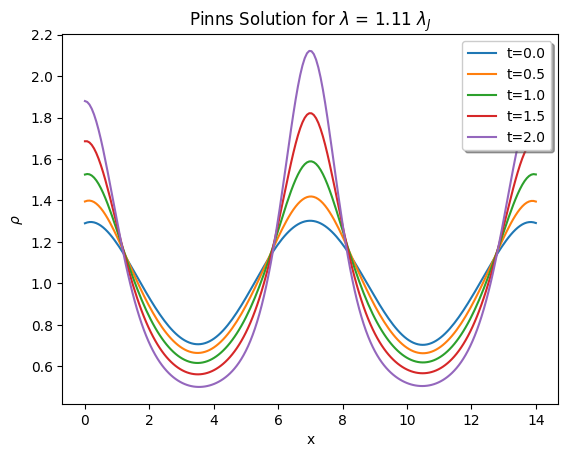

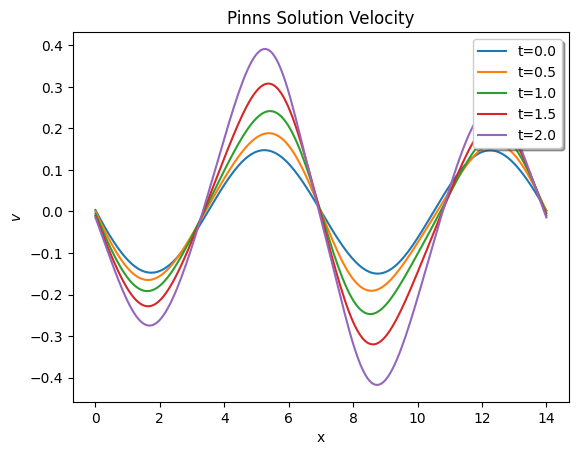

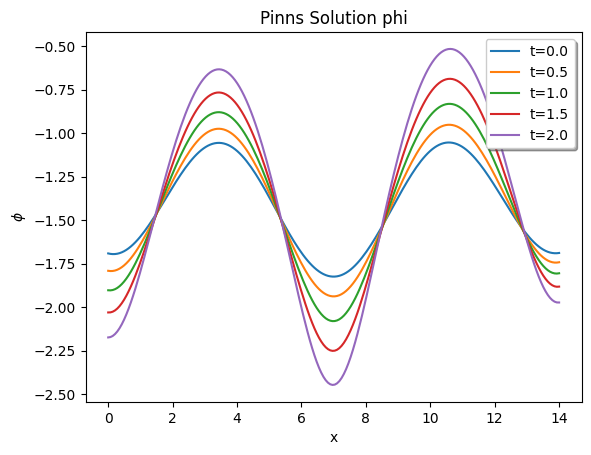

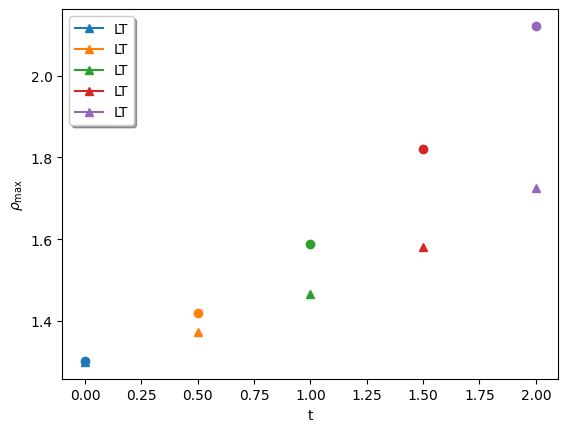

In [21]:
#import Plotting as pt
time_array = np.linspace(0,int(tmax),int(tmax)+3)
initial_params = xmin,xmax,rho_1, alpha ,lam,tmax ## required for plotting
plot_function(net,time_array,initial_params,velocity=True,isplot =True)

In [11]:
from LAX_2D import lax_solution
import numpy as np

## Parameters for the LAX method    
nu = 0.5            # COURANT number
N = 200            # number of grid points

import time

# start = time.time()
# # t = 1          # time till integrate
# # LAX.lax_solution1D(t,N,nu,lam,num_of_waves,rho_1,gravity=True,isplot = True,comparison = True)
# end = time.time()
# print("Total time = {} sec for N= {}".format(end - start,N))


time_array = np.asarray([0.5,1.5,tmax])
for time_ in time_array:
    lax_solution(time_,N,nu,lam,num_of_waves,rho_1,gravity=True,isplot = True,comparison = True,animation=None)

ModuleNotFoundError: No module named 'LAX_2D'

NameError: name 'lax_solution' is not defined

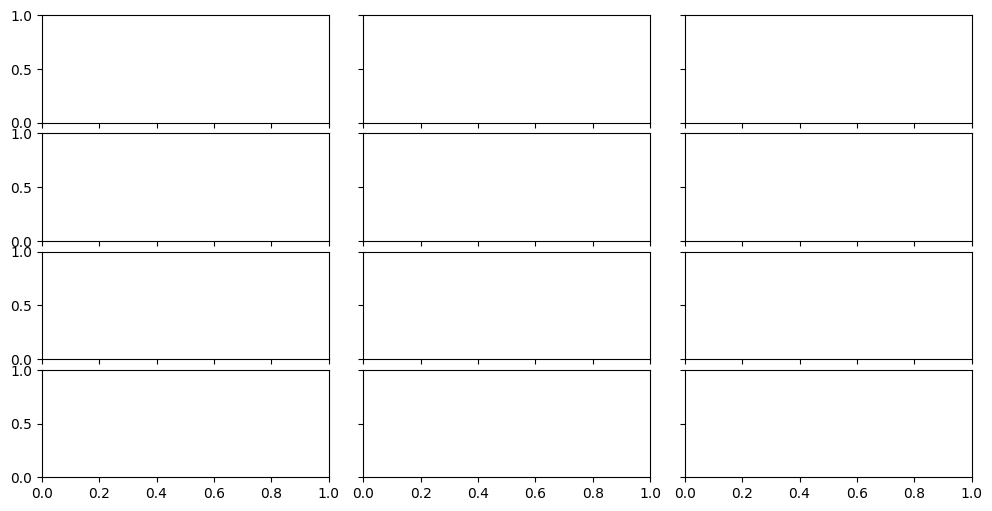

In [12]:
plt.style.use('default')
plt.rc('grid', linestyle='-', color='black', linewidth=0.05)
time_array = np.asarray([0.5,1.5,2.5])
fig, axes = plt.subplots(4, 3, sharex=True, sharey='row',figsize=(12,6),gridspec_kw={'width_ratios':[1,1,1], 'height_ratios':[4,4,4,4]})
plt.subplots_adjust(wspace=0.12, hspace=0.1)
initial_params = xmin,xmax,rho_1, alpha ,lam,tmax

for time,j in zip(time_array,range(3)):
    
    x,rho,v,phi,n,rho_LT,rho_LT_max,rho_max,v_LT = lax_solution(time, N, nu, lam, num_of_waves, rho_1, gravity = True, isplot = False, comparison = True)

    X, rho_pred0, v_pred0, phi_pred0, rho_max_PN, rho_theory = plot_function(net, time, initial_params, velocity = True, isplot = False, animation = True)

    # First row - density plots
    axes[0][j].plot(X,rho_pred0,color='c',linewidth=5,label="PN")    
    axes[0][j].plot(X,rho_LT,linestyle='dashed',color ='firebrick',linewidth=3,label="LT")
    axes[0][j].plot(x,rho[:,1],linestyle='solid',color = 'black',linewidth=1.0,label="FD")
    axes[0][j].set_xlim(xmin,xmax)
    axes[0][j].set_title("Time={}".format(round(time,2)))
    axes[0][j].grid("True")
    axes[0][j].minorticks_on()
    axes[0][j].tick_params(labelsize=10)
    axes[0][j].tick_params(axis='both', which='major',length=4, width=2)
    axes[0][j].tick_params(axis='both', which='minor',length=2, width=1)
    limu = 1.2*rho_o
    liml = .8*rho_o
    axes[0][j].set_ylim(liml,limu)
    
    # Second row - error plots
    axes[1][j].plot(x,(rho_pred0[:,0]- rho[:,1])/((rho_pred0[:,0]+ rho[:,1])/2)*100,color = 'black',linewidth=1,label="FD")
    axes[1][j].plot(x,(rho_pred0[:,0]-rho_LT)/((rho_pred0[:,0]+ rho_LT)/2)*100,color = 'b',linewidth=1,label="LT")
    axes[1][j].set_xlabel("x",fontsize = 18)
    axes[1][j].grid("True")
    axes[1][j].minorticks_on()
    axes[1][j].tick_params(labelsize=10)
    axes[1][j].tick_params(axis='both', which='major',length=4, width=2)
    axes[1][j].tick_params(axis='both', which='minor',length=2, width=1.)
    axes[1][j].set_ylim(-15.0,15.0)
    axes[1][j].set_xlim(xmin,xmax)
    
    # Third row - velocity plots
    axes[2][j].plot(X,v_pred0,color='c',linewidth=5,label="PN")    
    axes[2][j].plot(X,v_LT,linestyle='dashed',color ='firebrick',linewidth=3,label="LT")
    axes[2][j].plot(x,v[:,1],linestyle='solid',color = 'black',linewidth=1.0,label="FD")
    axes[2][j].grid("True")
    axes[2][j].minorticks_on()
    axes[2][j].tick_params(labelsize=8)
    axes[2][j].tick_params(axis='both', which='major',length=2, width=1)
    axes[2][j].tick_params(axis='both', which='minor',length=1, width=1)
    limu = 0.1
    liml = -0.1
    axes[2][j].set_ylim(liml,limu)
    
    # Fourth row - velocity error plots
    axes[3][j].plot(x,(v_pred0[:,0]+1- (v[:,1]+1))/((v_pred0[:,0]+1+ v[:,1]+1)/2)*100,color = 'black',linewidth=1,label="FD")
    axes[3][j].plot(x,(v_pred0[:,0]+1- (v_LT+1))/((v_pred0[:,0]+1+ (v_LT+1))/2)*100,color = 'b',linewidth=1,label="LT")
    axes[3][j].set_xlabel("x",fontsize = 18)
    axes[3][j].grid("True")
    axes[3][j].minorticks_on()
    axes[3][j].tick_params(labelsize=8)
    axes[3][j].tick_params(axis='both', which='major',length=2, width=1)
    axes[3][j].tick_params(axis='both', which='minor',length=1, width=1.)
    axes[3][j].set_ylim(-15,15)
    axes[3][j].set_xlim(xmin,xmax)

# Set labels and legends AFTER the loop
axes[0][0].set_ylabel(r"$\rho$",fontsize = 18)
axes[1][0].set_ylabel(r"$\epsilon$",fontsize = 18)
axes[2][0].set_ylabel(r"$v$",fontsize = 18)
axes[3][0].set_ylabel(r"$\epsilon$",fontsize = 18)

# Add legends only to the rightmost subplots after all plotting is done
axes[0][2].legend(loc='best',fancybox=False, shadow=False, ncol=3,fontsize = 10)
axes[1][2].legend(loc='upper right', bbox_to_anchor=(1.0, 1.0), fancybox=False, shadow=False, ncol=2, fontsize=10)
axes[2][2].legend(loc='best',fancybox=False, shadow=False, ncol=3,fontsize = 10)
axes[3][2].legend(loc='best',fancybox=False, shadow=False, ncol=3,fontsize = 10)

# Add text annotation
axes[0][0].text(0.42, 0.82, r"$\rho_1$ = {}, $\lambda$ = {} $\lambda_J$ ".format(rho_1,round(lam/(2*np.pi),2)),
                fontsize = 12, horizontalalignment='center', verticalalignment='center', 
                transform=axes[0][0].transAxes)


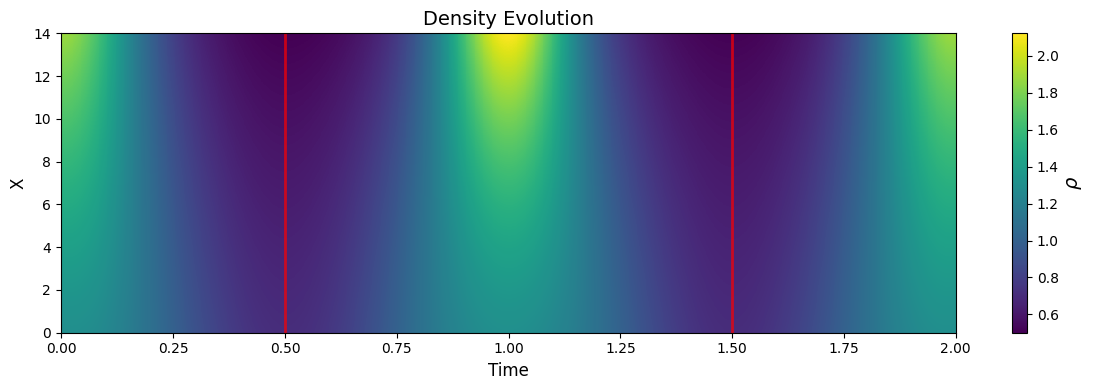

In [22]:
#import matplotlib.pyplot as plt

Y_cut = Z_cut = 0.6
Q = 1000

# Create 1D arrays for x and t
x_1d = np.linspace(xmin, xmax, Q)  # Reduced size for efficiency
t_1d = np.linspace(0, tmax, Q)

# Create meshgrid - this gives you all combinations
x_mesh, t_mesh = np.meshgrid(x_1d, t_1d)

# Flatten the meshgrids to create coordinate arrays
X_flat = x_mesh.flatten().reshape(-1, 1)
T_flat = t_mesh.flatten().reshape(-1, 1)
Y_flat = Y_cut * np.ones_like(X_flat)   
Z_flat = Z_cut * np.ones_like(X_flat)   

# Convert to PyTorch tensors
pt_x_collocation = torch.from_numpy(X_flat).float().to(device)
pt_y_collocation = torch.from_numpy(Y_flat).float().to(device)
#pt_z_collocation = torch.from_numpy(Z_flat).float().to(device)
pt_t_collocation = torch.from_numpy(T_flat).float().to(device)

# Create input for network
test_coor = [pt_x_collocation, pt_y_collocation, pt_t_collocation]

# Get predictions
output_0 = net(test_coor)
rho_pred0 = output_0[:,0:1].data.cpu().numpy()

# Now reshape back to grid format
Z_reshape = rho_pred0.reshape(Q, Q)  # This will work because we have Q0 predictions

# CREATE THE FIGURE AND AXES
fig, ax = plt.subplots(figsize=(12, 4))

# Create the plot
pc = ax.pcolormesh(t_1d, x_1d, Z_reshape, shading='auto', cmap='viridis')

# Add colorbar
cbar = plt.colorbar(pc, ax=ax)
cbar.set_label(r'$\rho$', fontsize=14)

# Labels and formatting
ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('X', fontsize=12)
ax.set_title('Density Evolution', fontsize=14)

# Add vertical lines at specific times (optional)
time_points = [0.5, 1.5, 2.5]  # Adjust based on your tmax
for t_point in time_points:
    if t_point <= tmax:  # Only add lines within the time range
        ax.axvline(x=t_point, color='red', linewidth=2, alpha=0.7)

plt.tight_layout()
plt.show()


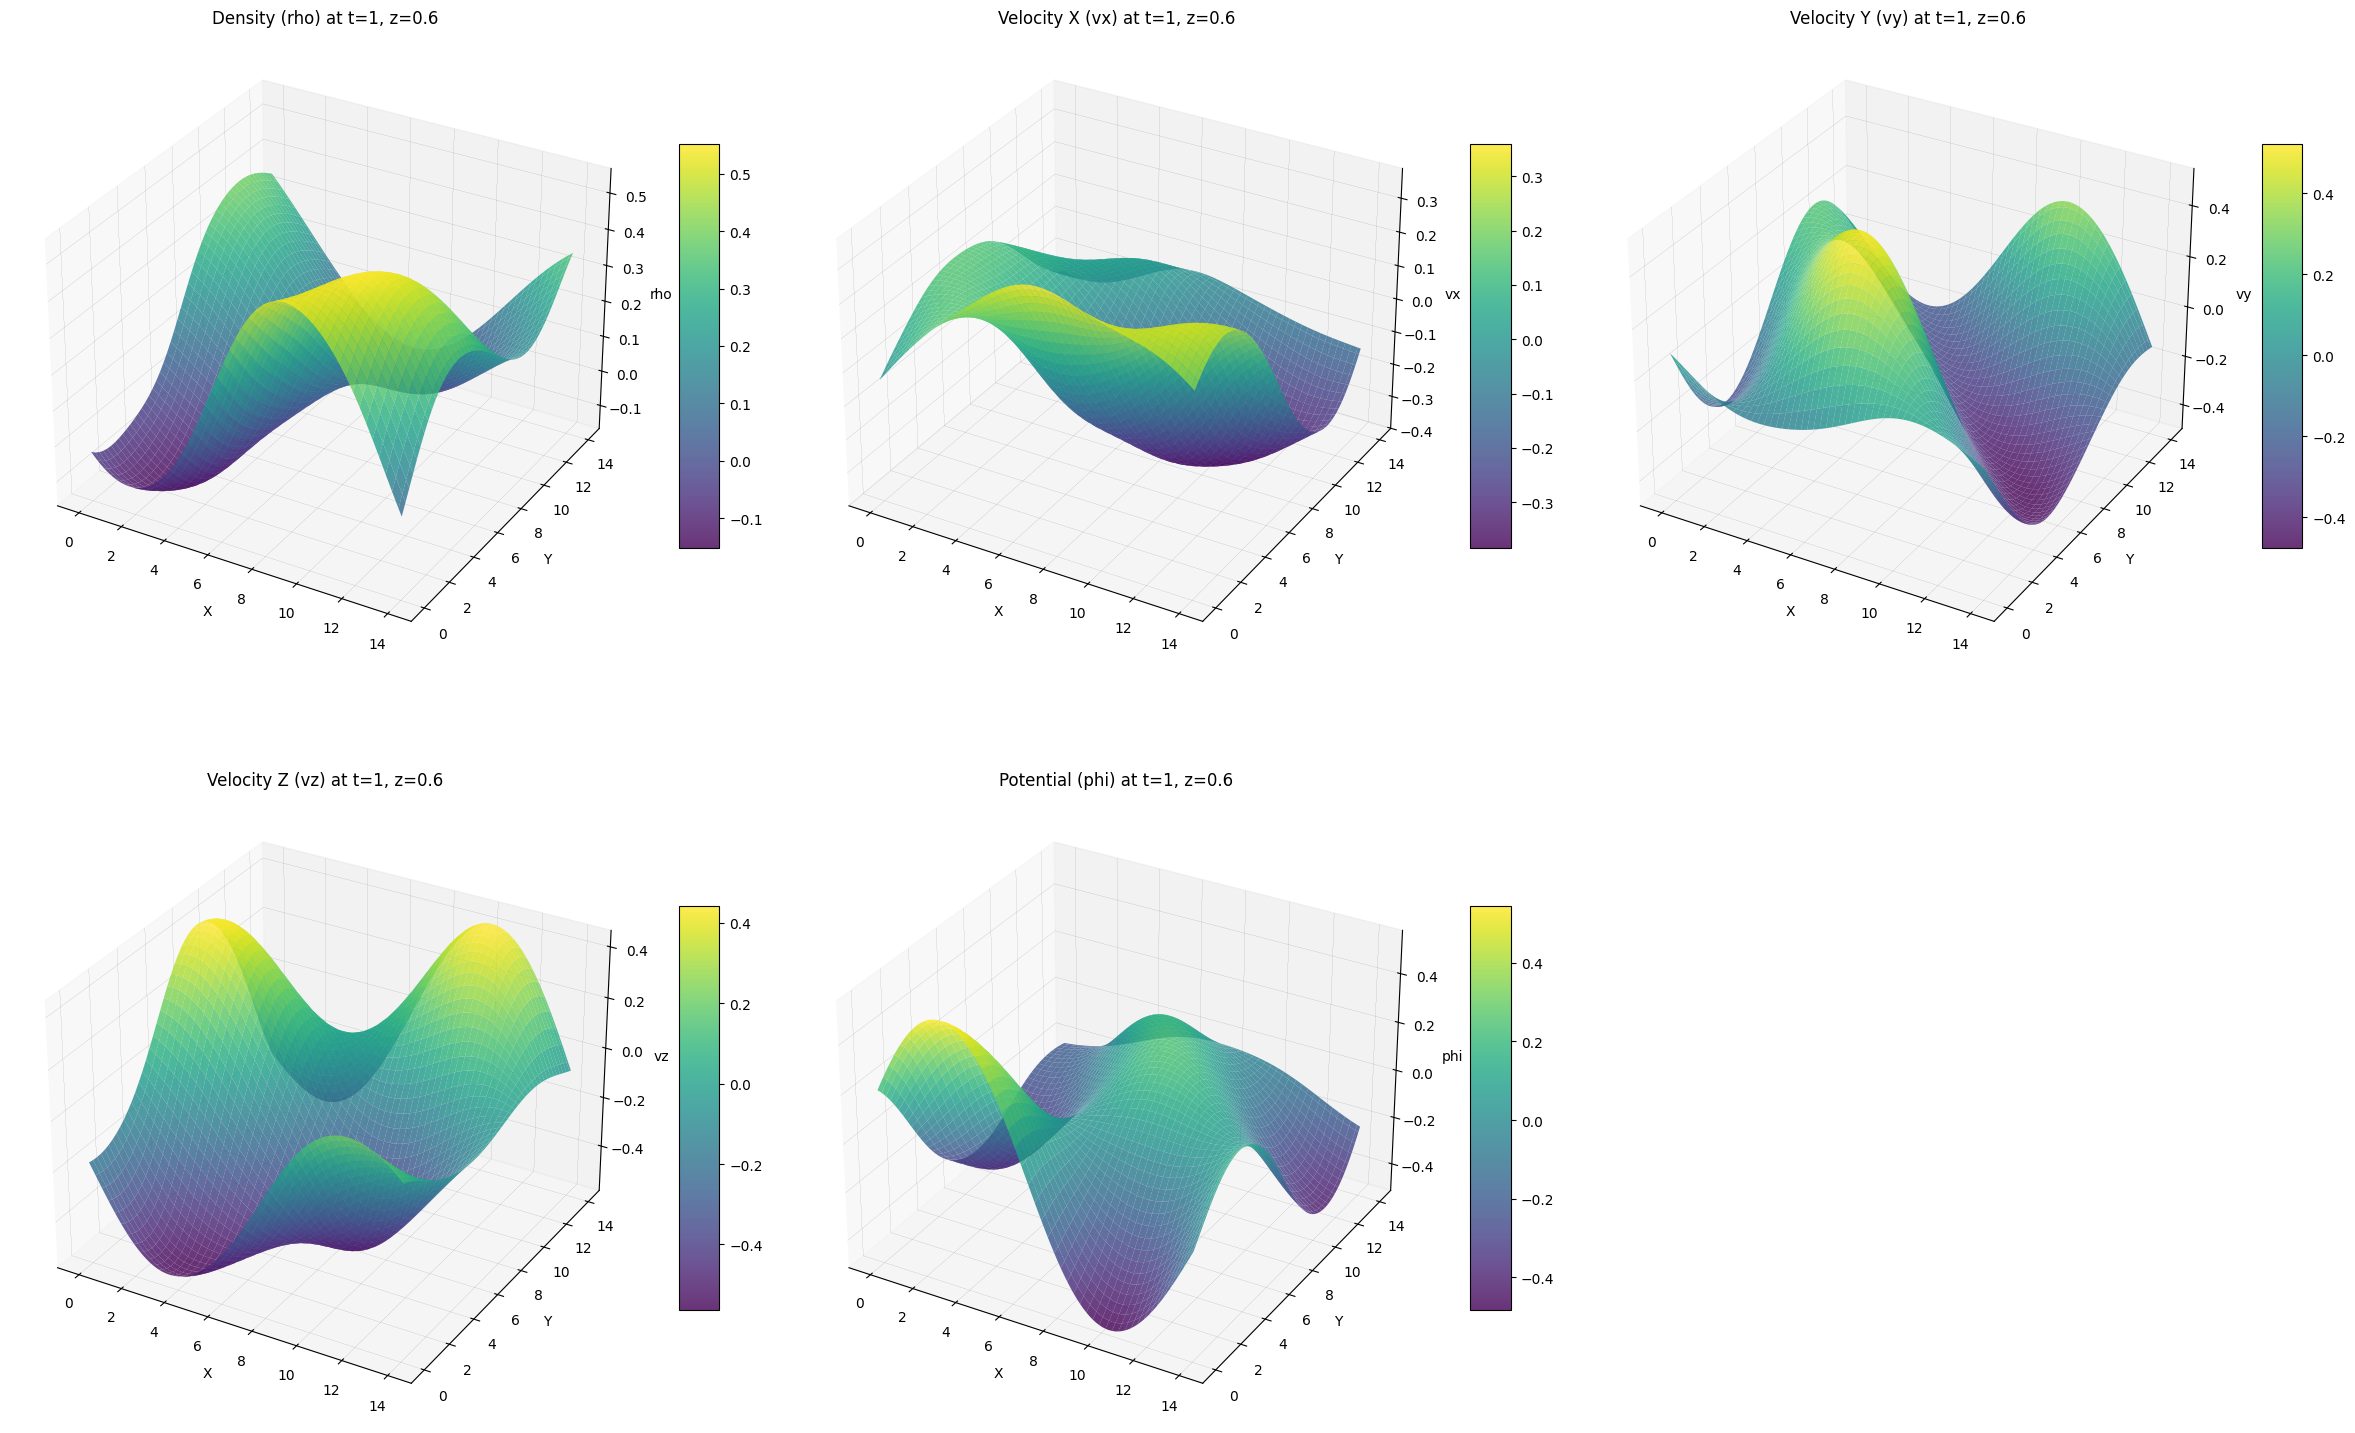

In [23]:
from scipy import stats
from mpl_toolkits.mplot3d import Axes3D 

Q = 100
Time = 1
xs = np.linspace(0, xmax, Q).reshape(Q, 1)
ys = np.linspace(0, ymax, Q).reshape(Q, 1)
zs = 0.6

xx, yy = np.meshgrid(xs, ys)

# Flatten the meshgrid to create coordinate arrays
x_flat = xx.flatten().reshape(-1, 1)
y_flat = yy.flatten().reshape(-1, 1)
z_flat = np.full_like(x_flat, zs)  # Fixed z-coordinate
t_flat = np.full_like(x_flat, Time)  # Fixed time

pt_x = Variable(torch.from_numpy(x_flat).float(), requires_grad=True).to(device)
pt_y = Variable(torch.from_numpy(y_flat).float(), requires_grad=True).to(device)
pt_z = Variable(torch.from_numpy(z_flat).float(), requires_grad=True).to(device)
pt_t = Variable(torch.from_numpy(t_flat).float(), requires_grad=True).to(device)

test_coor = [pt_x, pt_y, pt_z, pt_t]

with torch.no_grad():
    output = net(test_coor)
    rho = output[:, 0].cpu().numpy()
    vx = output[:, 1].cpu().numpy()
    vy = output[:, 2].cpu().numpy() 
    vz = output[:, 3].cpu().numpy()
    phi = output[:, 4].cpu().numpy()

rho_grid = rho.reshape(Q, Q)
vx_grid = vx.reshape(Q, Q)
vy_grid = vy.reshape(Q, Q)
vz_grid = vz.reshape(Q, Q)
phi_grid = phi.reshape(Q, Q)

fig = plt.figure(figsize=(24, 16))

# Density (rho)
ax1 = fig.add_subplot(231, projection='3d')
surf1 = ax1.plot_surface(xx, yy, rho_grid, cmap='viridis', alpha=0.8)
ax1.set_title(f'Density (rho) at t={Time}, z={zs}')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('rho')
fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10)

# vx
ax2 = fig.add_subplot(232, projection='3d')
surf2 = ax2.plot_surface(xx, yy, vx_grid, cmap='viridis', alpha=0.8)
ax2.set_title(f'Velocity X (vx) at t={Time}, z={zs}')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('vx')
fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=10)

# vy
ax3 = fig.add_subplot(233, projection='3d')
surf3 = ax3.plot_surface(yy, xx, vy_grid, cmap='viridis', alpha=0.8)
ax3.set_title(f'Velocity Y (vy) at t={Time}, z={zs}')
ax3.set_xlabel('X')
ax3.set_ylabel('Y')
ax3.set_zlabel('vy')
fig.colorbar(surf3, ax=ax3, shrink=0.5, aspect=10)

# vz
ax4 = fig.add_subplot(234, projection='3d')
surf4 = ax4.plot_surface(yy, xx, vz_grid, cmap='viridis', alpha=0.8)
ax4.set_title(f'Velocity Z (vz) at t={Time}, z={zs}')
ax4.set_xlabel('X')
ax4.set_ylabel('Y')
ax4.set_zlabel('vz')
fig.colorbar(surf4, ax=ax4, shrink=0.5, aspect=10)

# phi
ax5 = fig.add_subplot(235, projection='3d')
surf5 = ax5.plot_surface(xx, yy, phi_grid, cmap='viridis', alpha=0.8)
ax5.set_title(f'Potential (phi) at t={Time}, z={zs}')
ax5.set_xlabel('X')
ax5.set_ylabel('Y')
ax5.set_zlabel('phi')
fig.colorbar(surf5, ax=ax5, shrink=0.5, aspect=10)

plt.tight_layout()
plt.show()


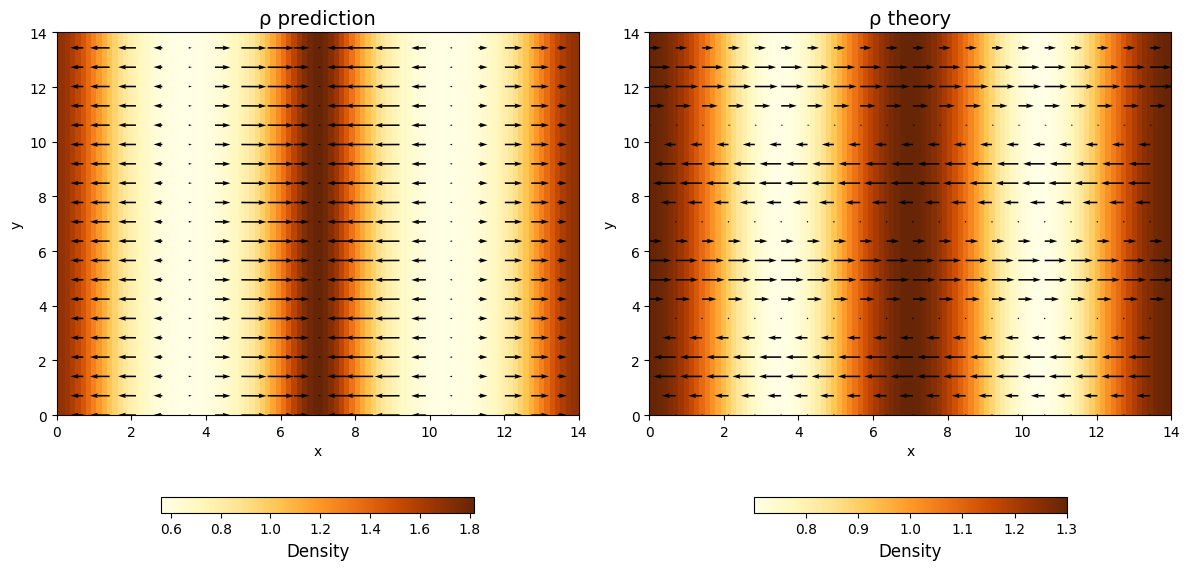

In [24]:
def fun_rho_0_mod(x):
    rho_0 = rho_o + rho_1 * torch.cos(2*np.pi*x/lam)    
    return rho_0

def create_vector_field_comparison(time):
    Time = time
    Q = 100
    
    # Use your original coordinate setup
    x = np.linspace(0, xmax, Q)
    y = np.linspace(0, ymax, Q)
    X, Y = np.meshgrid(x, y)
    
    # Flatten coordinates for network input (your original format)
    x_flat = X.flatten().reshape(-1, 1)
    y_flat = Y.flatten().reshape(-1, 1)
    z_flat = np.full_like(x_flat, 0.6)  # Fixed z
    t_flat = np.full_like(x_flat, Time)  # Use the time parameter
    
    # Convert to tensors (your original format)
    pt_x = torch.from_numpy(x_flat).float().to(device)
    pt_y = torch.from_numpy(y_flat).float().to(device)
    #pt_z = torch.from_numpy(z_flat).float().to(device)
    pt_t = torch.from_numpy(t_flat).float().to(device)
    
    # Your original network input format
    test_coor = [pt_x, pt_y, pt_t]
    
    # Get network predictions (your original call)
    with torch.no_grad():
        output = net(test_coor)
        rho_pred = output[:, 0].cpu().numpy()
        vx_pred = output[:, 1].cpu().numpy()
        vy_pred = output[:, 2].cpu().numpy()
    
    # Reshape back to grid
    rho_pred_grid = rho_pred.reshape(X.shape)
    vx_pred_grid = vx_pred.reshape(X.shape)
    vy_pred_grid = vy_pred.reshape(X.shape)
    
    # Get theory data
    rho_theory = fun_rho_0_mod(torch.tensor(X)).numpy()
    v_0x_theory = fun_v_0(torch.tensor(X)).numpy()
    v_0y_theory = np.full(np.shape(v_0x_theory), 0.0)

    v_0x_theory = np.broadcast_to(v_0x_theory[:, np.newaxis], (Q, Q))
    v_0y_theory = np.zeros((Q, Q))

    # Create the plots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
    
    # Left plot - Prediction
    im1 = ax1.pcolormesh(X, Y, rho_pred_grid, cmap='YlOrBr', shading='auto')
    skip = (slice(None, None, 5), slice(None, None, 5))
    ax1.quiver(X[skip], Y[skip], vx_pred_grid[skip], vy_pred_grid[skip], 
               color='k', headwidth=3.0, width=0.003)
    ax1.set_title('ρ prediction', fontsize=14)
    ax1.set_xlabel('x')
    ax1.set_ylabel('y')
    ax1.set_xlim(xmin, xmax)
    ax1.set_ylim(ymin, ymax)
    
    cbar1 = plt.colorbar(im1, ax=ax1, shrink=0.6, location='bottom')
    cbar1.formatter.set_powerlimits((0, 0))
    cbar1.ax.set_xlabel('Density', fontsize=12)
    
    # Right plot - Theory
    im2 = ax2.pcolormesh(X, Y, rho_theory, cmap='YlOrBr', shading='auto')
    ax2.quiver(X[skip], Y[skip], v_0x_theory[skip], v_0y_theory[skip], 
               color='k', headwidth=3.0, width=0.003)
    ax2.set_title('ρ theory', fontsize=14)
    ax2.set_xlabel('x')
    ax2.set_ylabel('y')
    ax2.set_xlim(xmin, xmax)
    ax2.set_ylim(ymin, ymax)
    
    cbar2 = plt.colorbar(im2, ax=ax2, shrink=0.6, location='bottom')
    cbar2.formatter.set_powerlimits((0, 0))
    cbar2.ax.set_xlabel('Density', fontsize=12)
    
    plt.tight_layout()
    plt.show()

# Usage
create_vector_field_comparison(time=1.5)